In [17]:
import tensorflow as tf
import numpy as np
import os

In [18]:
FRESHNESS_LABELS = {
    'fresh':   0,
    'aging':   1,
    'spoiled': 2,
}

# Crops that have all 3 stages (fresh / aging / spoiled)
THREE_STAGE_CROPS = ['carrot', 'mango', 'potato', 'tomato', 'plantain', 'pepper']


# Crops that only have 2 stages (fresh / spoiled — no aging folder)
TWO_STAGE_CROPS = ['cucumber', 'okra', 'orange']

# Days remaining per crop per stage
# Pulled directly from SHELF_LIFE_DAYS in model.py
SHELF_LIFE_DAYS = {
    'tomato':   {'fresh': 7,  'aging': 3,  'spoiled': 0},
    'plantain': {'fresh': 6,  'aging': 3,  'spoiled': 0},
    'pepper': {'fresh': 8,  'aging': 3,  'spoiled': 0},
    'carrot':   {'fresh': 14, 'aging': 5,  'spoiled': 0},
    'mango':    {'fresh': 6,  'aging': 2,  'spoiled': 0},
    'potato':   {'fresh': 21, 'aging': 7,  'spoiled': 0},
    'cucumber': {'fresh': 7,  'aging': 3,  'spoiled': 0},
    'okra':     {'fresh': 4,  'aging': 2,  'spoiled': 0},
    'oranges':  {'fresh': 14, 'aging': 5,  'spoiled': 0},
}

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

In [19]:
def get_stages_for_crop(crop_name):
    """Return the valid stages for a given crop."""
    if crop_name in TWO_STAGE_CROPS:
        return ['fresh', 'spoiled']
    return ['fresh', 'aging', 'spoiled']

In [20]:
def get_stages_for_crop(crop_name):
    """Return the valid stages for a given crop."""
    if crop_name in TWO_STAGE_CROPS:
        return ['fresh', 'spoiled']
    return ['fresh', 'aging', 'spoiled']

In [21]:
IMG_SIZE = 224


def load_image(path, freshness_label, days_label):
    """
    Reads an image file from disk, decodes it safely (forcing RGB,
    handling any format among JPEG/PNG), and resizes with padding
    to preserve aspect ratio instead of stretching.
    """
    image_bytes = tf.io.read_file(path)

    image = tf.image.decode_image(image_bytes, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])  # required since decode_image doesn't set static shape

    # Preserve aspect ratio instead of stretch-resizing (pads with black)
    image = tf.image.resize_with_pad(image, IMG_SIZE, IMG_SIZE)
    image = tf.cast(image, tf.float32)  # MobileNetV2 preprocessing is baked into the model itself

    labels = {
        'freshness': freshness_label,
        'days_remaining': days_label
    }
    return image, labels


def augment_image(image, labels):
    """
    Light augmentation for training data only.
    """
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.15)
    image = tf.image.random_contrast(image, lower=0.85, upper=1.15)
    image = tf.clip_by_value(image, 0.0, 255.0)
    return image, labels




In [22]:
def build_dataset(data_dir, split='train', batch_size=BATCH_SIZE,
                  crop_filter=None):
    """
    Builds a tf.data.Dataset from your processed folder.

    Expected folder structure:
    data_dir/
        train/
            tomato/
                fresh/    <- .jpg and .png files here
                aging/
                spoiled/
            banana/
                fresh/
                aging/
                spoiled/
            cucumber/
                fresh/    <- no aging/ for 2-stage crops
                spoiled/
            ...
        validation/
            tomato/ ...
        test/
            tomato/ ...

    Args:
        data_dir:    Path to your processed/ folder
        split:       'train', 'validation', or 'test'
        batch_size:  How many images per batch (32 is standard)
        crop_filter: Optional — pass a crop name string to train
                     on one crop only (e.g. 'tomato')
                     Pass None to train on all crops together.

    Returns:
        tf.data.Dataset ready to pass into model.fit()
    """
    image_paths     = []
    freshness_list  = []
    days_list       = []

    split_dir = os.path.join(data_dir, split)

    if not os.path.exists(split_dir):
        raise FileNotFoundError(
            f"Split folder not found: {split_dir}\n"
            f"Check that your processed/ folder is at: {data_dir}"
        )

    all_crops = THREE_STAGE_CROPS + TWO_STAGE_CROPS

    # If crop_filter is set, only load that one crop
    crops_to_load = [crop_filter] if crop_filter else all_crops

    for crop in crops_to_load:
        crop_dir = os.path.join(split_dir, crop)

        if not os.path.exists(crop_dir):
            print(f"  SKIP (folder missing): {split}/{crop}")
            continue

        valid_stages = get_stages_for_crop(crop)

        for stage in valid_stages:
            stage_dir = os.path.join(crop_dir, stage)

            if not os.path.exists(stage_dir):
                print(f"  SKIP (folder missing): {split}/{crop}/{stage}")
                continue

            # Get freshness label (integer)
            label = FRESHNESS_LABELS[stage]

            # Get days remaining for this crop+stage
            days = SHELF_LIFE_DAYS.get(crop, {}).get(stage, 0.0)

            # Collect all image file paths
            images_found = 0
            for fname in os.listdir(stage_dir):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    image_paths.append(os.path.join(stage_dir, fname))
                    freshness_list.append(label)
                    days_list.append(float(days))
                    images_found += 1

            print(f"  {split:12} | {crop:10} | {stage:8} | {images_found} images")

    if len(image_paths) == 0:
        raise ValueError(
            f"No images found in {split_dir}.\n"
            f"Check that your folder structure matches the expected layout."
        )

    print(f"\n  Total {split}: {len(image_paths)} images\n")

    # Build the dataset from lists
    dataset = tf.data.Dataset.from_tensor_slices((
        image_paths,
        freshness_list,
        days_list
    ))

    # Load and decode each image
    dataset = dataset.map(
        lambda p, l, d: load_image(p, l, d),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # Apply augmentation to training data only
    if split == 'train':
        dataset = dataset.map(
            augment_image,
            num_parallel_calls=tf.data.AUTOTUNE
        )
        dataset = dataset.shuffle(buffer_size=1000, seed=42)

    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return dataset

In [23]:
# Cap for minimum images per crop_stage folder (before augmentation is even applied)
MIN_IMAGES_PER_CLASS = 300


def build_dataset(data_dir, split='train', batch_size=BATCH_SIZE,
                  crop_filter=None, oversample=True, min_images=MIN_IMAGES_PER_CLASS):
    """
    Builds a tf.data.Dataset from your processed folder.
    Expected folder structure:
    data_dir/
        train/
            tomato_fresh/
            tomato_aging/
            tomato_spoiled/
            cucumber_fresh/
            cucumber_spoiled/
            ...
        val/ ...
        test/ ...

    Args:
        data_dir:    Path to your dataset folder
        split:       'train', 'val', or 'test'
        batch_size:  How many images per batch (32 is standard)
        crop_filter: Optional — restrict to one crop
        oversample:  If True, duplicate file paths for small classes up to min_images.
                     Only applied when split == 'train' (val/test stay untouched
                     so evaluation reflects real-world distribution).
        min_images:  Minimum image count per crop_stage folder after oversampling.
    Returns:
        tf.data.Dataset ready to pass into model.fit()
    """
    image_paths = []
    freshness_list = []
    days_list = []

    split_dir = os.path.join(data_dir, split)
    if not os.path.exists(split_dir):
        raise FileNotFoundError(
            f"Split folder not found: {split_dir}\n"
            f"Check that your dataset folder is at: {data_dir}"
        )

    all_crops = THREE_STAGE_CROPS + TWO_STAGE_CROPS
    crops_to_load = [crop_filter] if crop_filter else all_crops

    for crop in crops_to_load:
        valid_stages = get_stages_for_crop(crop)
        for stage in valid_stages:
            folder_name = f"{crop}_{stage}"
            stage_dir = os.path.join(split_dir, folder_name)

            if not os.path.exists(stage_dir):
                print(f"  SKIP (folder missing): {split}/{folder_name}")
                continue

            label = FRESHNESS_LABELS[stage]
            days = SHELF_LIFE_DAYS.get(crop, {}).get(stage, 0.0)

            folder_paths = [
                os.path.join(stage_dir, fname)
                for fname in os.listdir(stage_dir)
                if fname.lower().endswith(('.jpg', '.jpeg', '.png'))
            ]
            images_found = len(folder_paths)

            # Oversample only for training, only for small classes
            if oversample and split == 'train' and images_found > 0 and images_found < min_images:
                repeats = int(np.ceil(min_images / images_found))
                folder_paths = (folder_paths * repeats)[:min_images]
                print(
                    f"  {split:12} | {crop:10} | {stage:8} | {images_found} images -> oversampled to {len(folder_paths)}")
            else:
                print(f"  {split:12} | {crop:10} | {stage:8} | {images_found} images")

            image_paths.extend(folder_paths)
            freshness_list.extend([label] * len(folder_paths))
            days_list.extend([float(days)] * len(folder_paths))

    if len(image_paths) == 0:
        raise ValueError(
            f"No images found in {split_dir}.\n"
            f"Check that your folder structure matches the expected layout."
        )

    print(f"\n  Total {split}: {len(image_paths)} images\n")

    dataset = tf.data.Dataset.from_tensor_slices((
        image_paths,
        freshness_list,
        days_list
    ))

    dataset = dataset.map(
        lambda p, l, d: load_image(p, l, d),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if split == 'train':
        dataset = dataset.map(
            augment_image,
            num_parallel_calls=tf.data.AUTOTUNE
        )
        dataset = dataset.shuffle(buffer_size=2000, seed=42)

    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

In [24]:
if __name__ == '__main__':
    # Quick test — run this to confirm data_loader works
    # Update this path to your actual processed/ folder
    DATA_DIR = '/Users/addosakah/Desktop/COE3/Sem 2/Software engineering/AgriConnect project/AgriConnect AI/AgriConnect_Final_dataset'

    print("Testing data loader...\n")
    print("TRAIN:")
    test_ds = build_dataset(DATA_DIR, split='test')

    print("VALIDATION:")
    train_ds = build_dataset(DATA_DIR, split='train')

    print("TEST:")
    val_ds = build_dataset(DATA_DIR, split='val')

    # Check one batch shape
    for images, labels in train_ds.take(1):
        print(f"\nBatch shape:     {images.shape}")
        print(f"Freshness labels: {labels['freshness'].numpy()}")
        print(f"Days remaining:   {labels['days_remaining'].numpy()}")
        print("\ndata_loader.py is working correctly.")

Testing data loader...

TRAIN:
  test         | carrot     | fresh    | 186 images
  test         | carrot     | aging    | 18 images
  test         | carrot     | spoiled  | 52 images
  test         | mango      | fresh    | 544 images
  test         | mango      | aging    | 66 images
  test         | mango      | spoiled  | 675 images
  test         | potato     | fresh    | 270 images
  test         | potato     | aging    | 270 images
  test         | potato     | spoiled  | 370 images
  test         | tomato     | fresh    | 255 images
  test         | tomato     | aging    | 22 images
  test         | tomato     | spoiled  | 353 images
  test         | plantain   | fresh    | 892 images
  test         | plantain   | aging    | 113 images
  test         | plantain   | spoiled  | 900 images
  test         | pepper     | fresh    | 693 images
  test         | pepper     | aging    | 33 images
  test         | pepper     | spoiled  | 630 images
  test         | cucumber   | fresh   

2026-07-24 16:14:39.872306: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [25]:
import os
import pandas as pd
import matplotlib.pyplot as plt


def scan_dataset_counts(data_dir, splits=('train', 'val', 'test')):
    """
    Walks the dataset folder structure directly and counts images
    per (split, crop, stage) combination. Fast — just os.listdir, no decoding.
    """
    records = []
    all_crops = THREE_STAGE_CROPS + TWO_STAGE_CROPS

    for split in splits:
        split_dir = os.path.join(data_dir, split)
        if not os.path.exists(split_dir):
            print(f"  Split folder missing: {split_dir}")
            continue

        for crop in all_crops:
            valid_stages = get_stages_for_crop(crop)
            for stage in valid_stages:
                folder_name = f"{crop}_{stage}"
                stage_dir = os.path.join(split_dir, folder_name)

                if not os.path.exists(stage_dir):
                    continue  # already know about these, skip silently here

                count = sum(
                    1 for f in os.listdir(stage_dir)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
                )
                records.append({
                    'split': split,
                    'crop': crop,
                    'stage': stage,
                    'folder': folder_name,
                    'count': count
                })

    return pd.DataFrame(records)


df = scan_dataset_counts(DATA_DIR)
print(f"Scanned {len(df)} folders, {df['count'].sum()} total images\n")
df.head(10)

Scanned 72 folders, 41321 total images



,split,crop,stage,folder,count
0,train,carrot,fresh,carrot_fresh,712
1,train,carrot,aging,carrot_aging,166
2,train,carrot,spoiled,carrot_spoiled,104
3,train,mango,fresh,mango_fresh,1242
4,train,mango,aging,mango_aging,1148
5,train,mango,spoiled,mango_spoiled,1337
6,train,potato,fresh,potato_fresh,456
7,train,potato,aging,potato_aging,6110
8,train,potato,spoiled,potato_spoiled,682
9,train,tomato,fresh,tomato_fresh,1580


Images per split:
split
test      8261
train    28111
val       4949
Name: count, dtype: int64



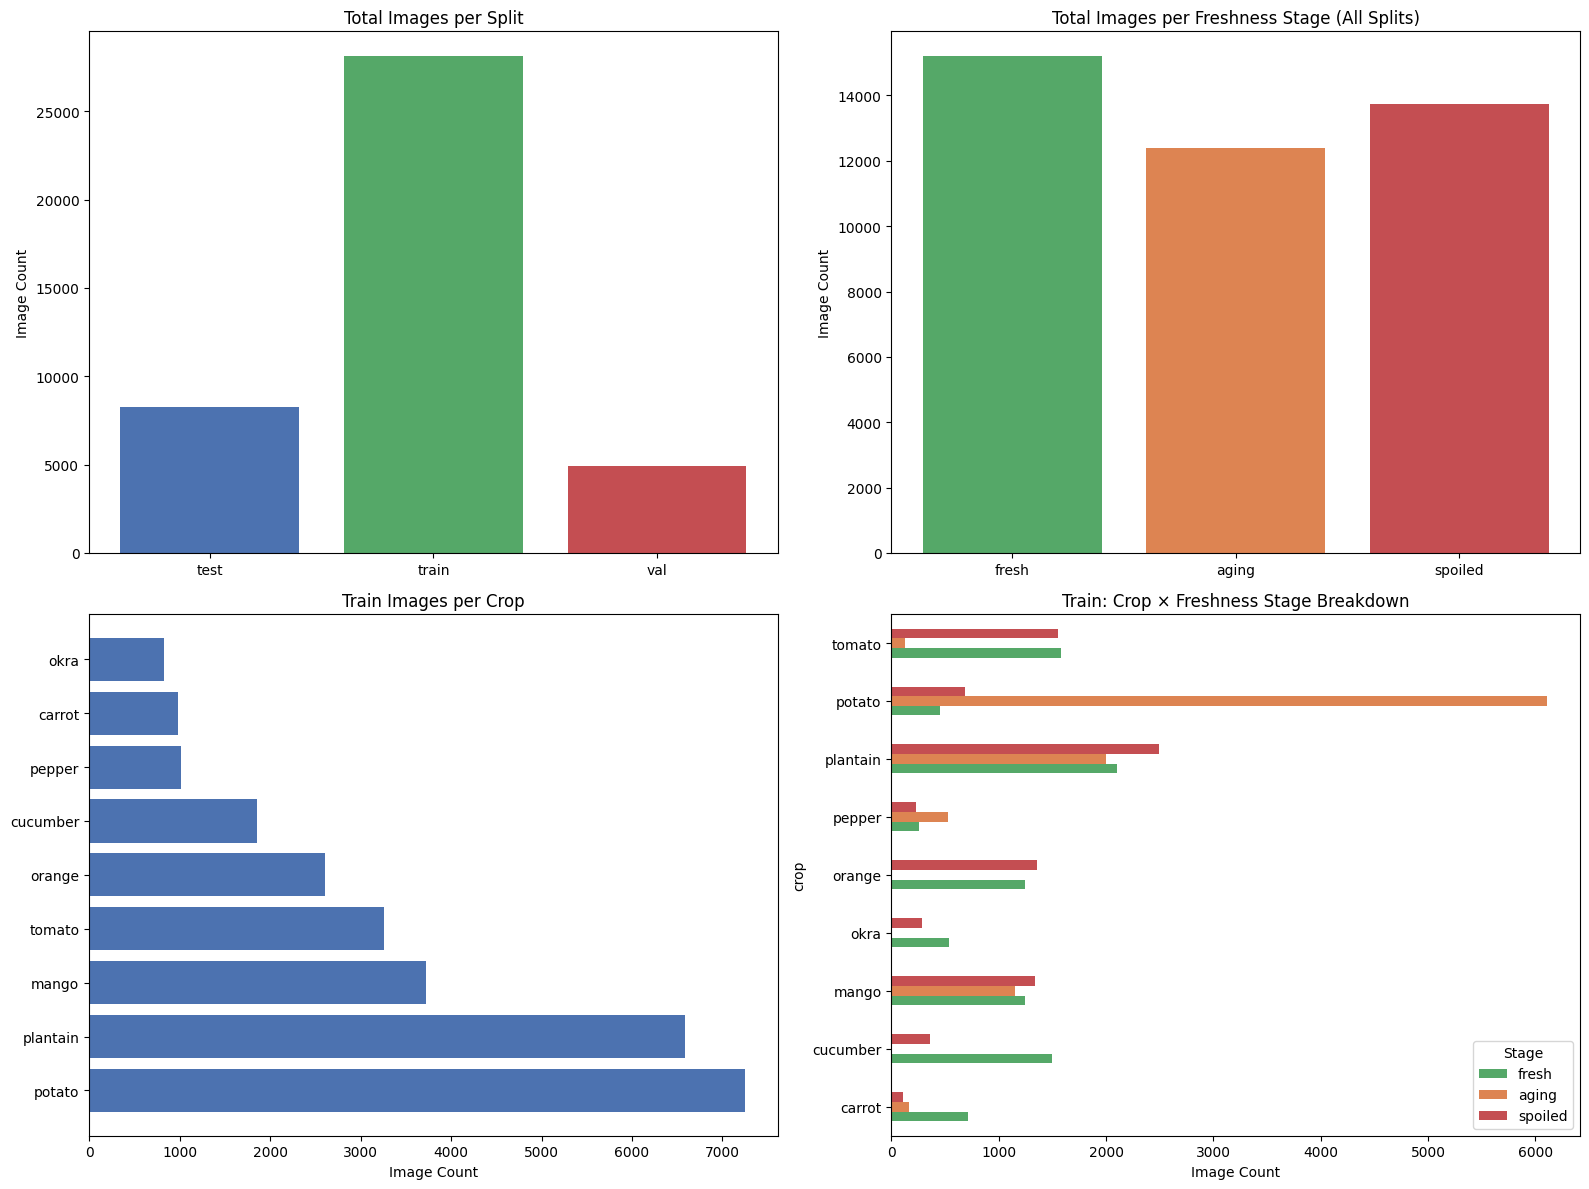

In [26]:
# --- 1. Total images per split ---
split_totals = df.groupby('split')['count'].sum()
print("Images per split:")
print(split_totals)
print()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Split totals
axes[0, 0].bar(split_totals.index, split_totals.values, color=['#4C72B0', '#55A868', '#C44E52'])
axes[0, 0].set_title('Total Images per Split')
axes[0, 0].set_ylabel('Image Count')

# --- 2. Freshness stage totals (fresh/aging/spoiled) across all data ---
stage_totals = df.groupby('stage')['count'].sum().reindex(['fresh', 'aging', 'spoiled'])
axes[0, 1].bar(stage_totals.index, stage_totals.values, color=['#55A868', '#DD8452', '#C44E52'])
axes[0, 1].set_title('Total Images per Freshness Stage (All Splits)')
axes[0, 1].set_ylabel('Image Count')

# --- 3. Images per crop (train split only, since that's what model learns from) ---
train_crop_totals = df[df['split'] == 'train'].groupby('crop')['count'].sum().sort_values(ascending=False)
axes[1, 0].barh(train_crop_totals.index, train_crop_totals.values, color='#4C72B0')
axes[1, 0].set_title('Train Images per Crop')
axes[1, 0].set_xlabel('Image Count')

# --- 4. Crop x Stage heatmap-style grouped bar (train split) ---
pivot = df[df['split'] == 'train'].pivot_table(
    index='crop', columns='stage', values='count', fill_value=0
)
pivot = pivot.reindex(columns=['fresh', 'aging', 'spoiled'])
pivot.plot(kind='barh', ax=axes[1, 1], color=['#55A868', '#DD8452', '#C44E52'])
axes[1, 1].set_title('Train: Crop × Freshness Stage Breakdown')
axes[1, 1].set_xlabel('Image Count')
axes[1, 1].legend(title='Stage')

plt.tight_layout()
plt.show()

In [27]:
# --- Imbalance check: min vs max class size within train split ---
train_df = df[df['split'] == 'train'].copy()
train_df = train_df.sort_values('count', ascending=False)

print("Train set — all crop_stage combos, sorted by count:")
print(train_df[['folder', 'count']].to_string(index=False))

print(f"\nLargest class:  {train_df.iloc[0]['folder']} ({train_df.iloc[0]['count']} images)")
print(f"Smallest class: {train_df.iloc[-1]['folder']} ({train_df.iloc[-1]['count']} images)")
print(f"Imbalance ratio: {train_df['count'].max() / train_df['count'].min():.1f}x")

Train set — all crop_stage combos, sorted by count:
          folder  count
    potato_aging   6110
plantain_spoiled   2493
  plantain_fresh   2098
  plantain_aging   1997
    tomato_fresh   1580
  tomato_spoiled   1552
  cucumber_fresh   1501
  orange_spoiled   1356
   mango_spoiled   1337
    orange_fresh   1247
     mango_fresh   1242
     mango_aging   1148
    carrot_fresh    712
  potato_spoiled    682
      okra_fresh    540
    pepper_aging    529
    potato_fresh    456
cucumber_spoiled    358
    okra_spoiled    288
    pepper_fresh    253
  pepper_spoiled    231
    carrot_aging    166
    tomato_aging    131
  carrot_spoiled    104

Largest class:  potato_aging (6110 images)
Smallest class: carrot_spoiled (104 images)
Imbalance ratio: 58.8x


In [28]:
import numpy as np

# Using freshness stage (0=fresh, 1=aging, 2=spoiled) as the class weight basis
stage_counts = df[df['split'] == 'train'].groupby('stage')['count'].sum()
stage_counts = stage_counts.reindex(['fresh', 'aging', 'spoiled'])

total = stage_counts.sum()
n_classes = len(stage_counts)

class_weights = {
    i: total / (n_classes * stage_counts[stage])
    for i, stage in enumerate(['fresh', 'aging', 'spoiled'])
}
print("Class weights (freshness):", class_weights)

Class weights (freshness): {0: 0.973136705092256, 1: 0.929504348113613, 2: 1.115383089314764}


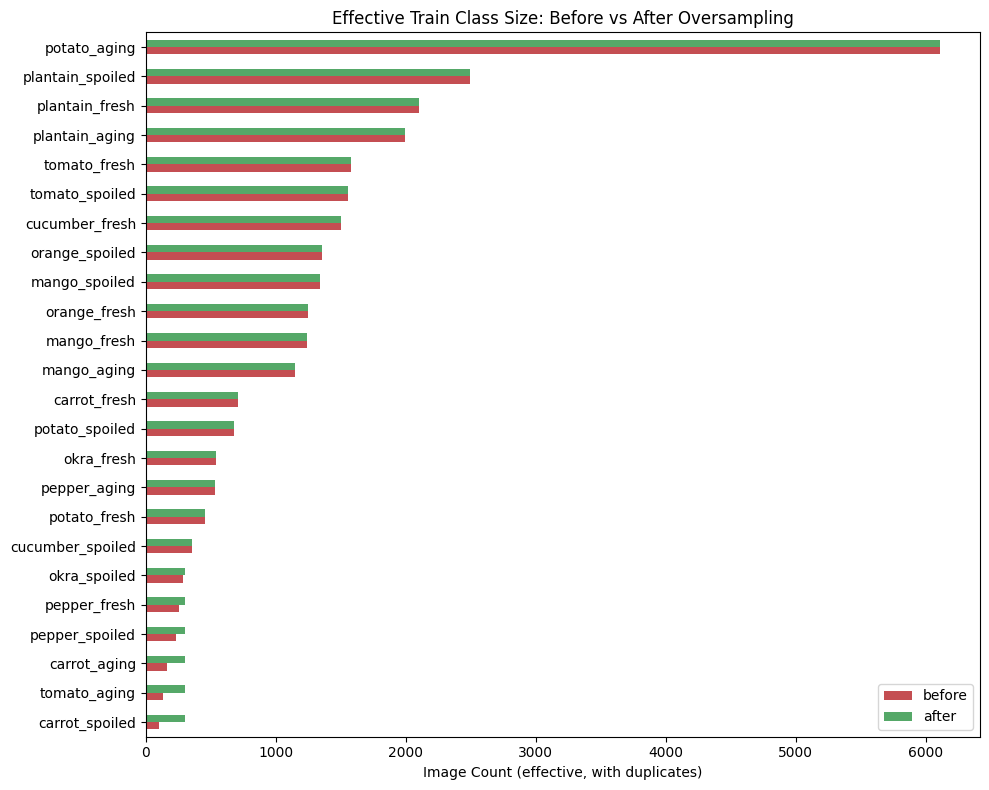

In [29]:
from collections import Counter


# Rebuild raw (no oversampling) counts for comparison
def get_train_class_counts(oversample):
    counts = {}
    all_crops = THREE_STAGE_CROPS + TWO_STAGE_CROPS
    for crop in all_crops:
        for stage in get_stages_for_crop(crop):
            folder_name = f"{crop}_{stage}"
            stage_dir = os.path.join(DATA_DIR, 'train', folder_name)
            if not os.path.exists(stage_dir):
                continue
            n = sum(1 for f in os.listdir(stage_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png')))
            if oversample and n < MIN_IMAGES_PER_CLASS and n > 0:
                n = MIN_IMAGES_PER_CLASS
            counts[folder_name] = n
    return counts


before = get_train_class_counts(oversample=False)
after = get_train_class_counts(oversample=True)

compare_df = pd.DataFrame({'before': before, 'after': after}).sort_values('before')

fig, ax = plt.subplots(figsize=(10, 8))
compare_df.plot(kind='barh', ax=ax, color=['#C44E52', '#55A868'])
ax.set_title('Effective Train Class Size: Before vs After Oversampling')
ax.set_xlabel('Image Count (effective, with duplicates)')
plt.tight_layout()
plt.show()

In [30]:
import random
from PIL import Image


def sample_image_properties(data_dir, split='train', samples_per_class=20, seed=42):
    """
    Samples a subset of images per crop_stage folder and inspects
    their dimensions and color mode — fast way to catch outliers
    without decoding the whole dataset.
    """
    random.seed(seed)
    records = []
    all_crops = THREE_STAGE_CROPS + TWO_STAGE_CROPS
    split_dir = os.path.join(data_dir, split)

    for crop in all_crops:
        for stage in get_stages_for_crop(crop):
            folder_name = f"{crop}_{stage}"
            stage_dir = os.path.join(split_dir, folder_name)
            if not os.path.exists(stage_dir):
                continue

            files = [f for f in os.listdir(stage_dir)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            if not files:
                continue

            sample = random.sample(files, min(samples_per_class, len(files)))

            for fname in sample:
                fpath = os.path.join(stage_dir, fname)
                try:
                    with Image.open(fpath) as img:
                        w, h = img.size
                        mode = img.mode
                    records.append({
                        'crop': crop, 'stage': stage, 'folder': folder_name,
                        'width': w, 'height': h,
                        'aspect_ratio': round(w / h, 2),
                        'mode': mode
                    })
                except Exception as e:
                    records.append({
                        'crop': crop, 'stage': stage, 'folder': folder_name,
                        'width': None, 'height': None,
                        'aspect_ratio': None, 'mode': f'ERROR: {e}'
                    })

    return pd.DataFrame(records)


props_df = sample_image_properties(DATA_DIR, split='train', samples_per_class=20)
print(f"Sampled {len(props_df)} images\n")
props_df.head(10)

Sampled 480 images



,crop,stage,folder,width,height,aspect_ratio,mode
0,carrot,fresh,carrot_fresh,275,183,1.50,RGB
1,carrot,fresh,carrot_fresh,275,183,1.50,RGB
2,carrot,fresh,carrot_fresh,100,100,1.00,RGB
3,carrot,fresh,carrot_fresh,259,194,1.34,RGB
4,carrot,fresh,carrot_fresh,275,183,1.50,RGB
5,carrot,fresh,carrot_fresh,224,224,1.00,RGB
6,carrot,fresh,carrot_fresh,100,100,1.00,RGB
7,carrot,fresh,carrot_fresh,275,183,1.50,RGB
8,carrot,fresh,carrot_fresh,224,224,1.00,RGB
9,carrot,fresh,carrot_fresh,224,224,1.00,RGB


In [31]:
print("Color mode distribution:")
print(props_df['mode'].value_counts())
print()

print("Width stats:")
print(props_df['width'].describe())
print()

print("Height stats:")
print(props_df['height'].describe())
print()

print("Aspect ratio stats:")
print(props_df['aspect_ratio'].describe())


Color mode distribution:
mode
RGB     471
RGBA      9
Name: count, dtype: int64

Width stats:
count    480.000000
mean     447.608333
std      148.740912
min      100.000000
25%      352.000000
50%      450.000000
75%      564.500000
max      762.000000
Name: width, dtype: float64

Height stats:
count    480.000000
mean     393.506250
std      154.147707
min      100.000000
25%      319.500000
50%      332.000000
75%      512.000000
max      640.000000
Name: height, dtype: float64

Aspect ratio stats:
count    480.000000
mean       1.177917
std        0.240812
min        0.560000
25%        1.000000
50%        1.000000
75%        1.410000
max        2.230000
Name: aspect_ratio, dtype: float64


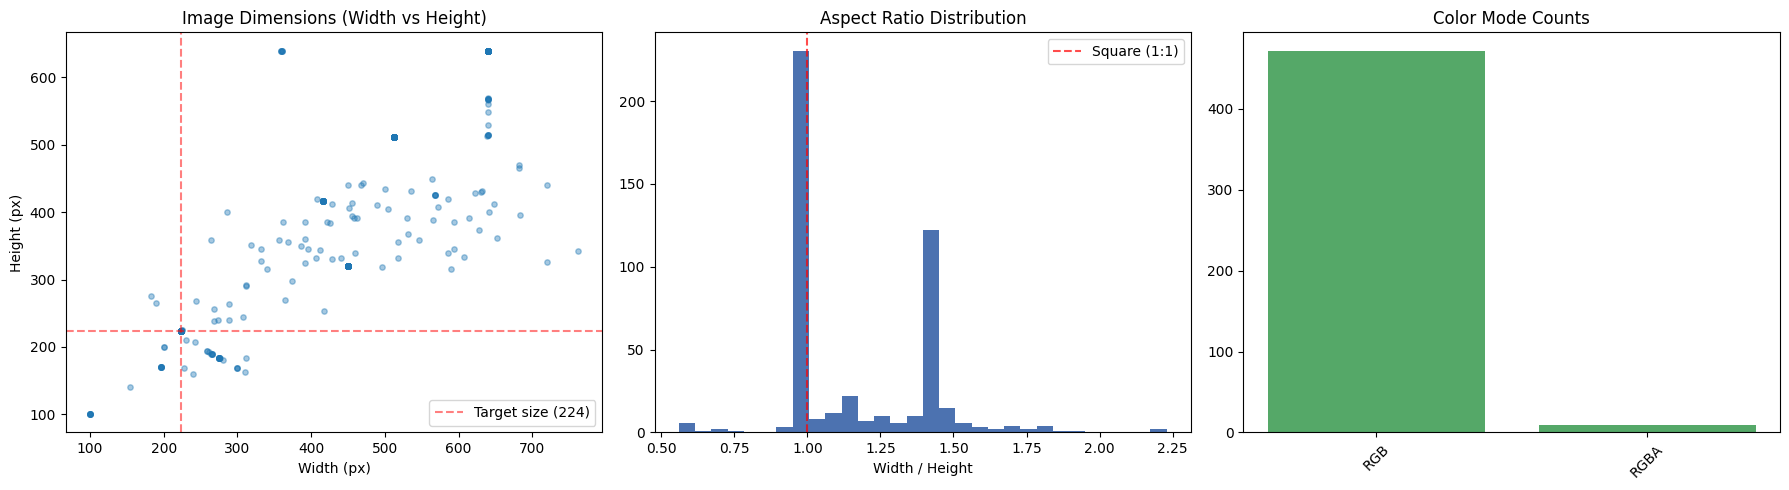

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(props_df['width'], props_df['height'], alpha=0.4, s=15)
axes[0].set_title('Image Dimensions (Width vs Height)')
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Height (px)')
axes[0].axvline(224, color='red', linestyle='--', alpha=0.5, label='Target size (224)')
axes[0].axhline(224, color='red', linestyle='--', alpha=0.5)
axes[0].legend()

axes[1].hist(props_df['aspect_ratio'].dropna(), bins=30, color='#4C72B0')
axes[1].set_title('Aspect Ratio Distribution')
axes[1].set_xlabel('Width / Height')
axes[1].axvline(1.0, color='red', linestyle='--', alpha=0.7, label='Square (1:1)')
axes[1].legend()

mode_counts = props_df['mode'].value_counts()
axes[2].bar(mode_counts.index, mode_counts.values, color='#55A868')
axes[2].set_title('Color Mode Counts')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [33]:
def verify_full_dataset(data_dir, splits=('train', 'val', 'test')):
    """
    Scans every image in the dataset (not just a sample) and checks:
    - file can be opened/decoded by TF (matches what load_image will hit)
    - color mode (RGB / RGBA / grayscale / etc.)
    - dimensions
    Returns a DataFrame of all results, plus a separate list of failures.
    """
    records = []
    failures = []
    all_crops = THREE_STAGE_CROPS + TWO_STAGE_CROPS

    for split in splits:
        split_dir = os.path.join(data_dir, split)
        if not os.path.exists(split_dir):
            continue

        for crop in all_crops:
            for stage in get_stages_for_crop(crop):
                folder_name = f"{crop}_{stage}"
                stage_dir = os.path.join(split_dir, folder_name)
                if not os.path.exists(stage_dir):
                    continue

                files = [f for f in os.listdir(stage_dir)
                         if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

                for fname in files:
                    fpath = os.path.join(stage_dir, fname)
                    try:
                        image_bytes = tf.io.read_file(fpath)
                        image = tf.image.decode_image(image_bytes, channels=3, expand_animations=False)
                        h, w = image.shape[0], image.shape[1]
                        records.append({
                            'split': split, 'crop': crop, 'stage': stage,
                            'path': fpath, 'width': w, 'height': h, 'status': 'OK'
                        })
                    except Exception as e:
                        failures.append({'path': fpath, 'error': str(e)})
                        records.append({
                            'split': split, 'crop': crop, 'stage': stage,
                            'path': fpath, 'width': None, 'height': None,
                            'status': f'FAIL: {e}'
                        })

    return pd.DataFrame(records), failures


full_df, failures = verify_full_dataset(DATA_DIR)
print(f"Total images checked: {len(full_df)}")
print(f"Failures: {len(failures)}")
if failures:
    print("\nFirst 20 failures:")
    for f in failures[:20]:
        print(f"  {f['path']} -> {f['error']}")

2026-07-24 16:15:40.077684: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2026-07-24 16:15:40.085972: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2026-07-24 16:15:40.093468: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2026-07-24 16:15:40.097373: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2026-07-24 16:15:40.101614: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2026-07-24 16:15:40.105435: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2026-07-24 16:15:40.108564: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2026-07-24 16:15:40.111981: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2026-07-24 16:15:40.120130: W tensorflow/core/lib/png/png_io.cc:89] PNG 

Total images checked: 41321
Failures: 0


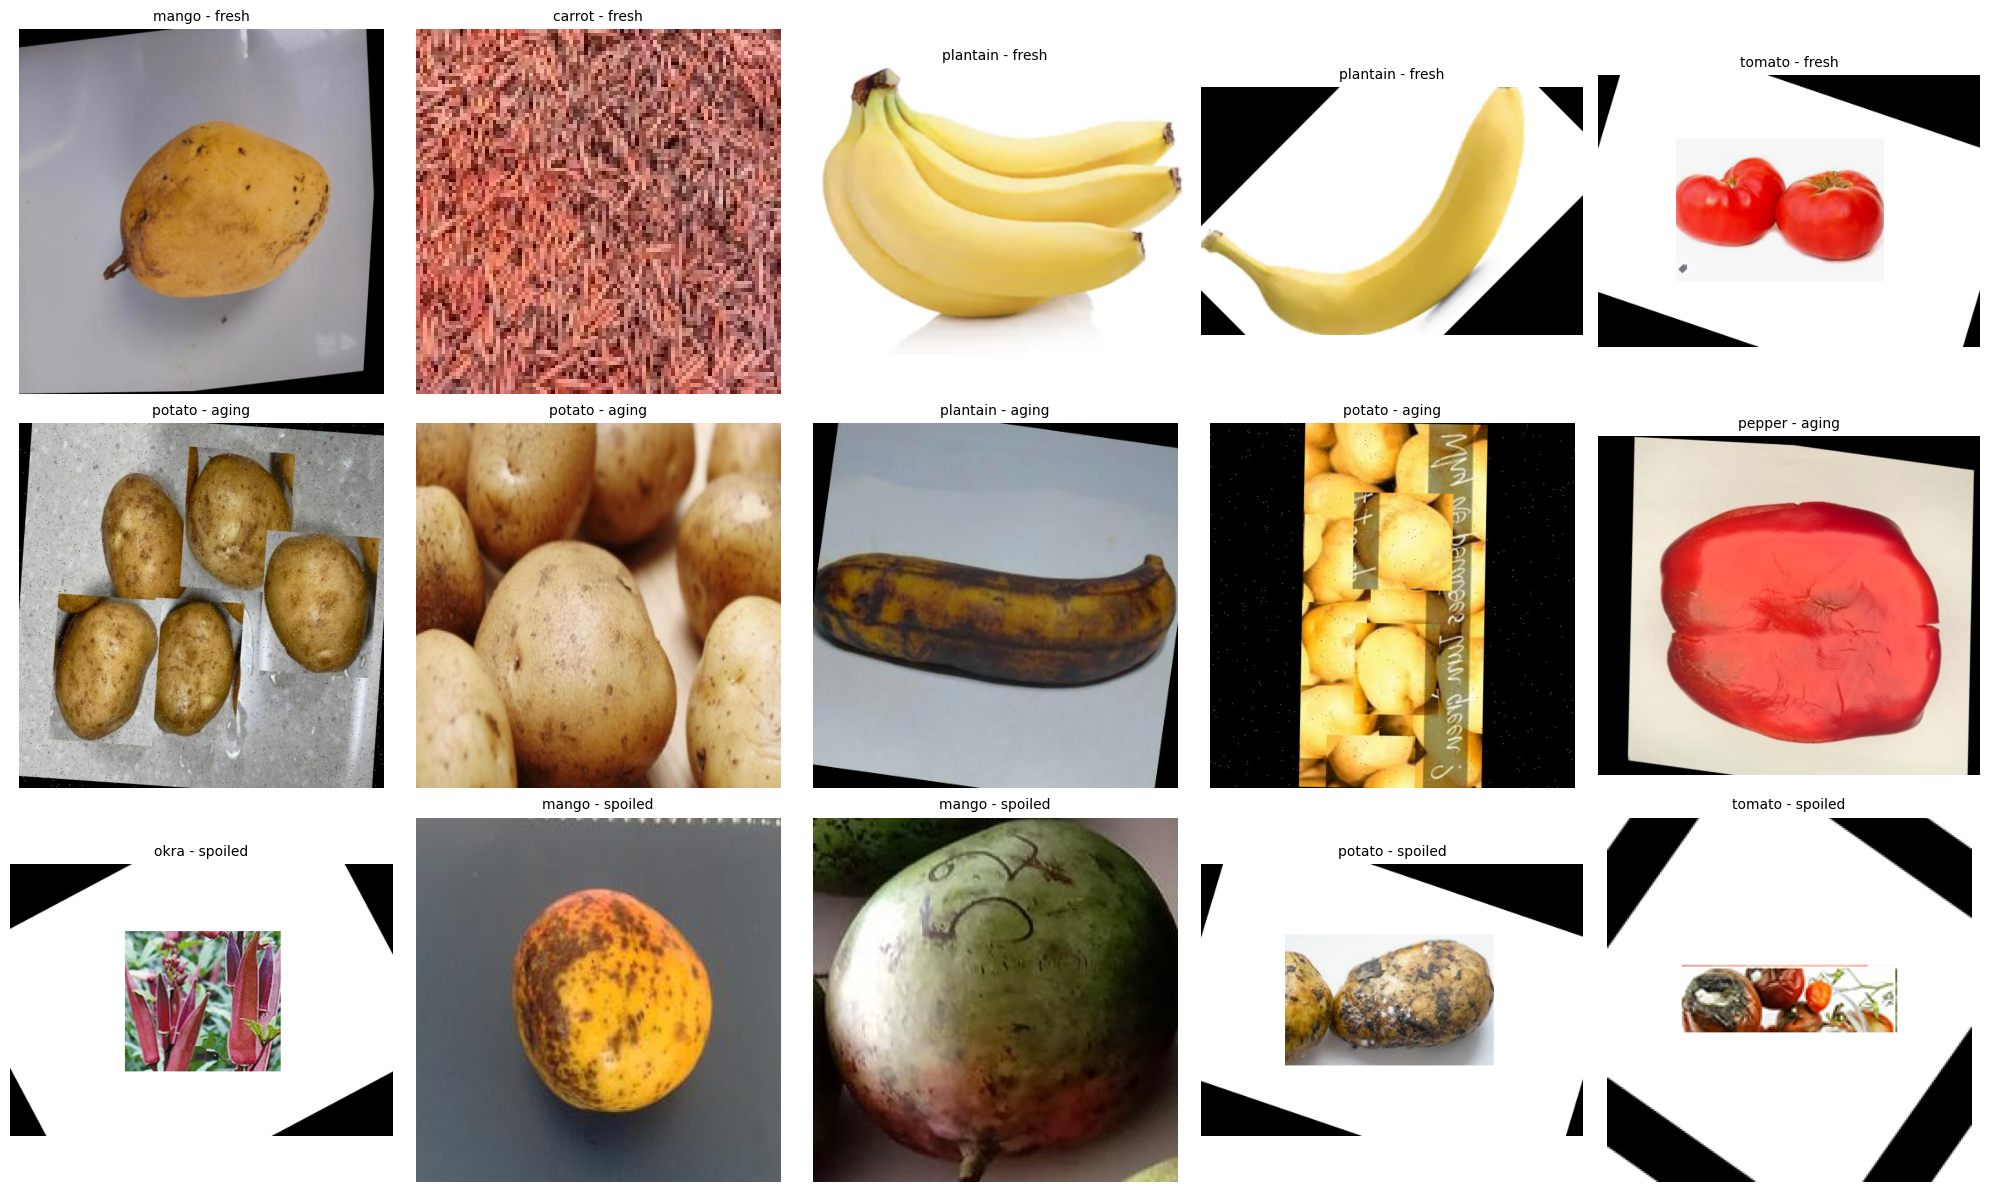

In [34]:
# --- Visual sample grid: a few images per freshness stage, across crops ---
import matplotlib.image as mpimg


def show_sample_grid(data_dir, split='train', n_per_stage=4, seed=42):
    random.seed(seed)
    stages = ['fresh', 'aging', 'spoiled']
    all_crops = THREE_STAGE_CROPS + TWO_STAGE_CROPS
    split_dir = os.path.join(data_dir, split)

    fig, axes = plt.subplots(len(stages), n_per_stage, figsize=(4 * n_per_stage, 4 * len(stages)))

    for row, stage in enumerate(stages):
        # gather candidate files across crops that have this stage
        candidates = []
        for crop in all_crops:
            if stage not in get_stages_for_crop(crop):
                continue
            stage_dir = os.path.join(split_dir, f"{crop}_{stage}")
            if not os.path.exists(stage_dir):
                continue
            files = [f for f in os.listdir(stage_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            candidates.extend([(crop, os.path.join(stage_dir, f)) for f in files])

        sample = random.sample(candidates, min(n_per_stage, len(candidates)))

        for col in range(n_per_stage):
            ax = axes[row, col]
            if col < len(sample):
                crop, fpath = sample[col]
                img = mpimg.imread(fpath)
                ax.imshow(img)
                ax.set_title(f"{crop} - {stage}", fontsize=10)
            ax.axis('off')

    plt.tight_layout()
    plt.show()


show_sample_grid(DATA_DIR, split='train', n_per_stage=5)

        crop    stage  days
2     carrot  spoiled     0
5      mango  spoiled     0
11    tomato  spoiled     0
8     potato  spoiled     0
14  plantain  spoiled     0
21      okra  spoiled     0
19  cucumber  spoiled     0
17    pepper  spoiled     0
4      mango    aging     2
16    pepper    aging     3
10    tomato    aging     3
13  plantain    aging     3
20      okra    fresh     4
1     carrot    aging     5
3      mango    fresh     6
12  plantain    fresh     6
7     potato    aging     7
18  cucumber    fresh     7
9     tomato    fresh     7
15    pepper    fresh     8
0     carrot    fresh    14
6     potato    fresh    21


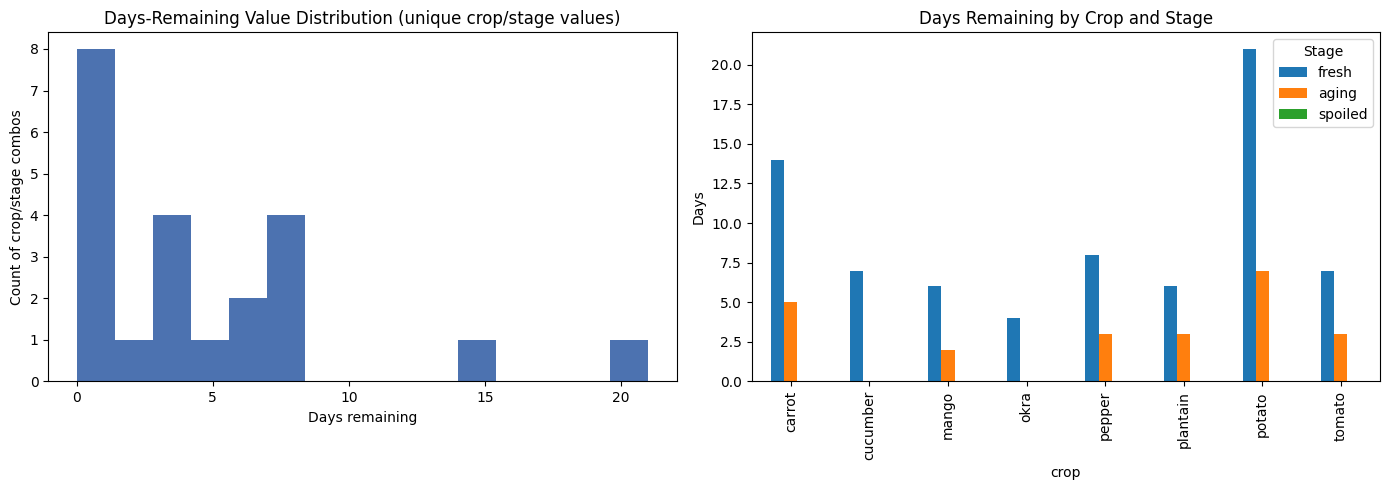

In [35]:
# --- Days-remaining distribution (regression target) ---
days_records = []
all_crops = THREE_STAGE_CROPS + TWO_STAGE_CROPS

for crop in all_crops:
    for stage in get_stages_for_crop(crop):
        days = SHELF_LIFE_DAYS.get(crop, {}).get(stage, None)
        if days is not None:
            days_records.append({'crop': crop, 'stage': stage, 'days': days})

days_df = pd.DataFrame(days_records)
print(days_df.sort_values('days'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(days_df['days'], bins=15, color='#4C72B0')
axes[0].set_title('Days-Remaining Value Distribution (unique crop/stage values)')
axes[0].set_xlabel('Days remaining')
axes[0].set_ylabel('Count of crop/stage combos')

days_pivot = days_df.pivot_table(index='crop', columns='stage', values='days')
days_pivot = days_pivot.reindex(columns=['fresh', 'aging', 'spoiled'])
days_pivot.plot(kind='bar', ax=axes[1])
axes[1].set_title('Days Remaining by Crop and Stage')
axes[1].set_ylabel('Days')
axes[1].legend(title='Stage')

plt.tight_layout()
plt.show()